In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

## Test Runs

Estimated value of Pi: 3.144


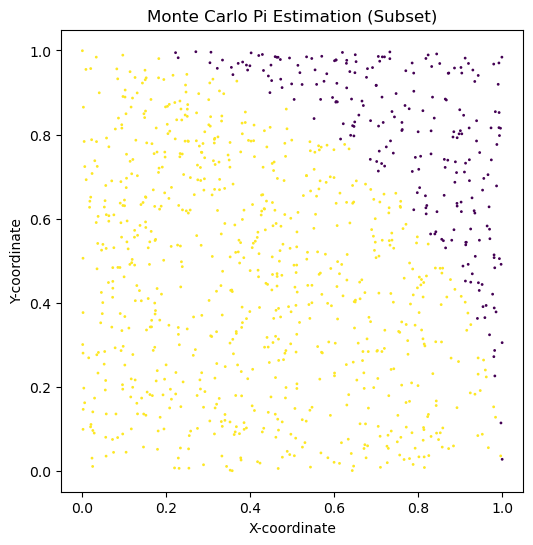

In [ ]:
## Estimating with points (VIBECODED):

import numpy as np
import matplotlib.pyplot as plt

def estimate_pi(num_samples):
    # Generate random x and y coordinates within a 1x1 square
    x = np.random.uniform(0, 1, num_samples)
    y = np.random.uniform(0, 1, num_samples)

    # Calculate the distance from the origin (0,0)
    distance = np.sqrt(x**2 + y**2)

    # Count points that fall within the inscribed quarter circle (distance <= 1)
    points_in_circle = np.sum(distance <= 1)

    # Estimate pi based on the ratio of areas
    pi_estimate = 4 * (points_in_circle / num_samples)
    return pi_estimate, x, y, distance

num_simulations = 100000 # Number of points to scatter
pi_approx, x, y, distance = estimate_pi(num_simulations)
print(f"Estimated value of Pi: {pi_approx}")

# Optional: Visualize a subset of the points
plt.figure(figsize=(6, 6))
plt.scatter(x[:1000], y[:1000], c=distance[:1000] <= 1, cmap='viridis', s=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Monte Carlo Pi Estimation (Subset)')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.show()

In [ ]:
## Actual Monte Carlo Simulation for paper (initial design)

def pi_para(C, A, m, n):
    return (2*C*n) / (A*m)

def pi_perp(C, A, m, n):
    return (4*C*n) / (A*m)

def para_sim(n_tpicks, trials, mean, C, A):
    trial_list = []
    m_list = []
    for i in range(trials):
        m = np.random.normal(loc=(2*C*n_tpicks)/(A*np.pi))
        m_list.append(m)
        trial_list.append(pi_para(C=C, A=A, m=np.sum(m_list), n=n_tpicks*(i+1)))
    error_list = [100*(np.abs(j-np.pi)/np.pi) for j in trial_list]
    return trial_list, error_list
    
def perp_sim(n_tpicks, trials, mean, C, A):
    trial_list = []
    m_list = []
    for i in range(trials):
        m = np.random.normal(loc=(2*C*n_tpicks)/(A*np.pi))
        m_list.append(m)
        trial_list.append(pi_perp(C=C, A=A, m=np.sum(m_list), n=n_tpicks*(i+1)))
    error_list = [100*(np.abs(j-np.pi)/np.pi) for j in trial_list]
    return trial_list, error_list

t1, e1 = para_sim(20, 1900, 6, 64, 130)

print(np.mean(t1), np.mean(e1))

## Takes too long to run, too many for-loops. Must vectorize.

3.1577673424124417 0.7076665942675259


## Actual Results

In [3]:
## Vectorized:

def para_sim(n_tpicks, trials, C, A):

    # Vectorize m_list for-loop
    m_list = np.random.normal(loc=(2*C*n_tpicks)/(A*np.pi), size=trials)
    m_cumsum = np.cumsum(m_list)
    # Vectorize taking the trial values and errorrs
    n_array = n_tpicks * np.arange(1, trials + 1)
    trial_array = (2 * C * n_array) / (A * m_cumsum)
    error_array = 100 * np.abs(trial_array - np.pi) / np.pi
    
    return trial_array, error_array

def perp_sim(n_tpicks, trials, C, A):

    # Vectorize m_list for-loop
    m_list = np.random.normal(loc=(4*C*n_tpicks)/(A*np.pi), size=trials)
    m_cumsum = np.cumsum(m_list)

    # Vectorize taknig the trial values and errors
    n_array = n_tpicks * np.arange(1, trials + 1)
    trial_array = (4 * C * n_array) / (A * m_cumsum)
    error_array = 100 * np.abs(trial_array - np.pi) / np.pi
    return trial_array, error_array

In [4]:
n = 100

iter_list = np.arange(500, 500+(500*n), 500)
t1_list = []
t2_list = [] 
e1_list = [] 
e2_list = []

for i in range(n):

    t1, e1 = para_sim(n, iter_list[i], 64, 130)
    t2, e2 = perp_sim(n, iter_list[i], 64, 100)

    t1_list.append(np.mean(t1))
    t2_list.append(np.mean(t2))
    e1_list.append(np.mean(e1))
    e2_list.append(np.mean(e2))

para = np.array([iter_list, t1_list, e1_list])
perp = np.array([iter_list, t2_list, e2_list])

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\David\AppData\Local\Temp\ipykernel_28788\1256663650.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.hlines(y=np.pi, xmin=0, xmax=np.max(para[0]), ls='-', color='black', label='Actual $\pi$')


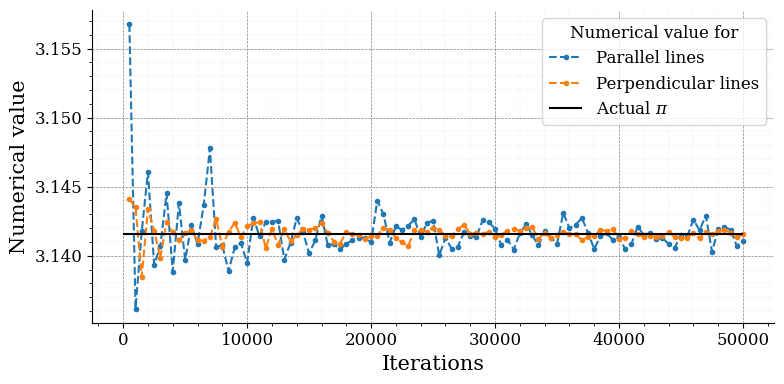

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.size'] = 12

plt.figure(figsize=(8, 4))
plt.plot(para[0], para[1], marker='.', ls='--', label='Parallel lines')
plt.plot(perp[0], perp[1], marker='.', ls='--', label='Perpendicular lines')

plt.hlines(y=np.pi, xmin=0, xmax=np.max(para[0]), ls='-', color='black', label='Actual $\pi$')

plt.xlabel('Iterations', fontsize=15)
plt.ylabel('Numerical value', fontsize=15)

plt.legend(frameon=True, title='Numerical value for')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()

# ax = plt.gca() # Get current axes
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

plt.savefig('Results/Numval_vs_iter.png', format='png', dpi=300)

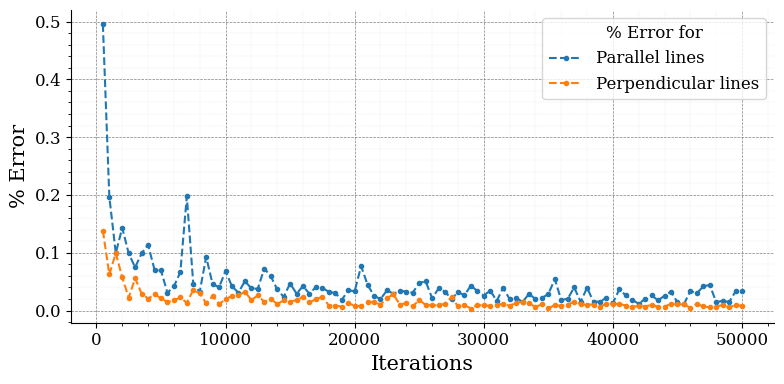

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(para[0], para[2], marker='.', ls='--', label='Parallel lines')
plt.plot(perp[0], perp[2], marker='.', ls='--', label='Perpendicular lines')

plt.xlabel('Iterations', fontsize=15)
plt.ylabel('% Error', fontsize=15)

plt.legend(frameon=True, title='% Error for')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()

ax = plt.gca() # Get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

plt.savefig('Results/%Error_vs_iter.png', format='png', dpi=300)

## Actually dropping toothpicks ##

Here I am using a different notation: L = length of toothpick, D = distance between lines

In [ ]:
# Test code
def buffon_parallel_lines(N, L, D, n_lines=10):
    """
    Buffon needle simulation for MANY PARALLEL LINES.
    
    N: number of toothpick to drop
    L: length of needle
    D: spacing between parallel lines
    n_lines: how many lines to include in the region
    """
    # Drop toothpick in a 1D space from x=0 to x=n_lines*D
    x_center = np.random.uniform(0, n_lines * D, size=N)
    
    theta = np.random.uniform(0, np.pi/2, size=N)

    # The projection of half the needle length perpendicular to the lines
    dx = (L/2) * np.sin(theta)

    # Distance to nearest line:
    # We find the remainder modulo D -> distance along repeating intervals
    dist_to_line = np.abs((x_center % D) - D/2)

    # Hit occurs if projection exceeds distance to nearest line
    hits = np.sum(dx >= dist_to_line)

    if hits == 0:
        return None

    pi_est = (2 * L * N) / (D * hits)
    return pi_est
pi_est = buffon_parallel_lines(N=2_000_000, L=1.3, D=2.1, n_lines=20)
print(pi_est)

3.1419390924230988


In [ ]:
def buffon_stream_parallel(N, L, D, n_lines=10):
    """
    Streaming Buffon needle simulation for MANY PARALLEL LINES.

    Returns arrays (length N):
    - pi_estimates[k] = π estimate after k+1 drops
    - hit_count[k]    = number of hits up to drop k+1
    """

    # Random center positions over an extended region with n_lines*D width
    x_center = np.random.uniform(0, n_lines * D, size=N)

    # Random orientation
    theta = np.random.uniform(0, np.pi/2, size=N)

    # Projection perpendicular to the lines
    dx = (L/2) * np.sin(theta)

    # Distance to nearest line using periodicity
    dist_to_line = np.abs((x_center % D) - D/2)

    # Hit check per drop
    hit = (dx >= dist_to_line).astype(int)

    # Running count of hits
    hits_cumsum = np.cumsum(hit)

    # Streaming π estimate
    pi_est = np.zeros(N)
    valid = hits_cumsum > 0
    pi_est[valid] = (2 * L * np.arange(1, N+1)[valid]) / (D * hits_cumsum[valid])

    return pi_est, hits_cumsum

def buffon_square_grid(N, L, D):
    """
    Streaming Buffon–Laplace simulation for a square grid (L <= D assumed).
    Returns:
      pi_estimates (array length N): running estimate of pi after each drop
      hits_cumsum (array length N): cumulative hits of any grid line
      both_cumsum (array length N): cumulative hits of both horizontal and vertical lines
    """
    # Random centers and angles
    x_center = np.random.uniform(0, D, size=N)
    y_center = np.random.uniform(0, D, size=N)
    theta = np.random.uniform(0, 2*np.pi, size=N)

    # Half-projections
    dx = (L/2) * np.abs(np.cos(theta))
    dy = (L/2) * np.abs(np.sin(theta))

    # Distance to nearest grid lines (correct)
    rx = x_center % D
    ry = y_center % D
    dist_x = np.minimum(rx, D - rx)
    dist_y = np.minimum(ry, D - ry)

    # Hits
    hit_x = dx >= dist_x
    hit_y = dy >= dist_y
    hit_any = (hit_x | hit_y).astype(int)
    hit_both = (hit_x & hit_y).astype(int)

    # Cumulative sums
    hits_cumsum = np.cumsum(hit_any)
    both_cumsum = np.cumsum(hit_both)

    # Running pi estimates using correct Buffon–Laplace formula:
    # P_hat = hits_cumsum / k  =>  pi = (4L - L^2/D) / (D * P_hat)
    k = np.arange(1, N+1)
    pi_est = np.zeros(N, dtype=float)
    valid = hits_cumsum > 0
    numerator = (4.0 * L) - (L*L / D)   # 4L - L^2/D
    pi_est[valid] = (numerator * k[valid]) / (D * hits_cumsum[valid])

    return pi_est, hits_cumsum, both_cumsum

# Adjust the following parameters to match our experiment #

In [86]:
## Parameters. Feel free to adjust!

Lparallel = 1.0  # Length of needle
Dparallel = 1.5  # Distance between lines
Lperp = 1  # Length of needle
Dperp = 1.5 # Distance between lines
TotalN = 10_001  # Total number of drops to simulate




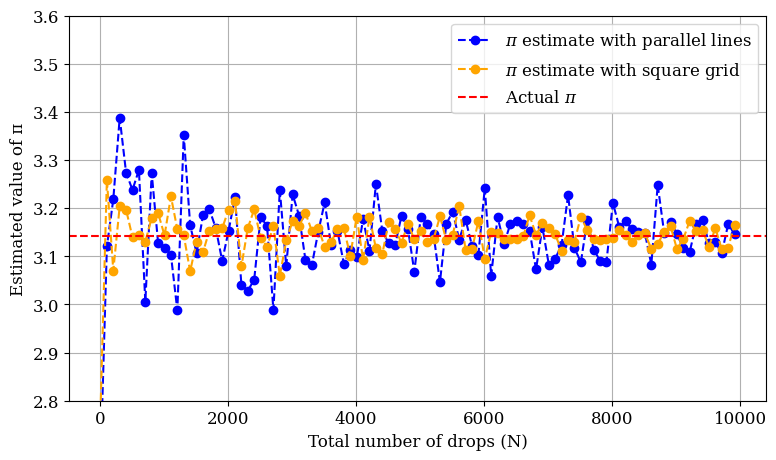

In [89]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.size'] = 12

# Range of total N to test
N_values = np.arange(10, TotalN, 100)  # vary how many total drops you want to compare
pi_parallel_final = []
pi_perp_final = []
hits_perp_final = []
both_hits_perp_final = []

for N in N_values:
    pi_est_parallel, hits_parallel = buffon_stream_parallel(N, Lparallel, Dparallel)
    pi_est_perp, hits_perp, both_hits_perp = buffon_square_grid(N, Lperp, Dperp)

    pi_parallel_final.append(pi_est_parallel[-1])  # take the final estimate for each N
    pi_perp_final.append(pi_est_perp[-1])
    hits_perp_final.append(hits_perp[-1])
    both_hits_perp_final.append(both_hits_perp[-1])   

# Plot convergence
plt.figure(figsize=(9,5))
plt.plot(N_values, pi_parallel_final, marker='o', linestyle='--', color='blue', label=r'$\pi$ estimate with parallel lines')
plt.plot(N_values, pi_perp_final, marker='o', linestyle='--', color='orange', label=r'$\pi$ estimate with square grid')
plt.axhline(np.pi, color='red', linestyle='--', label=r'Actual $\pi$')
plt.xlabel("Total number of drops (N)")
plt.ylabel("Estimated value of π")
#plt.title("Convergence of Buffon's Needle Estimate of π with increasing N")
plt.ylim(2.8, 3.6)
plt.grid(True)
plt.legend()
plt.show()

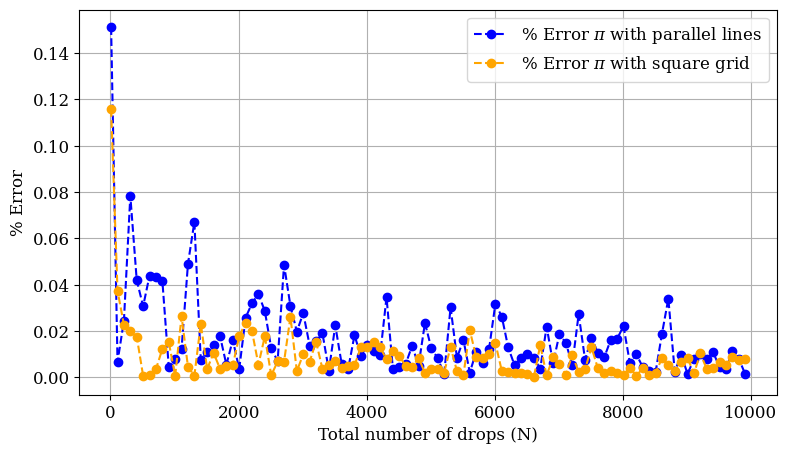

In [92]:
# Plot percent error convergence
np_pi_parallel_final = np.array(pi_parallel_final)
np_pi_perp_final = np.array(pi_perp_final)

plt.figure(figsize=(9,5))
plt.plot(N_values, np.abs(np_pi_parallel_final-np.pi)/np.pi, marker='o', linestyle='--', color='blue', label=r'$\%$ Error $\pi$ with parallel lines')
plt.plot(N_values, np.abs(np_pi_perp_final-np.pi)/np.pi, marker='o', linestyle='--', color='orange', label=r'$\%$ Error $\pi$ with square grid')
plt.xlabel("Total number of drops (N)")
plt.ylabel(r"$\%$ Error")
plt.grid(True)
plt.legend()
plt.show()



There is something interesting about the number of double hits vs. single hits [1]. We can find the ratio of double hits to single hits just from the ratio of the lengths of the grid and the toothpick. That is, we can find this ratio just from the geometry of our toothpick and gridlines instead of counting total hits!!


[1] https://mathworld.wolfram.com/Buffon-LaplaceNeedleProblem.html

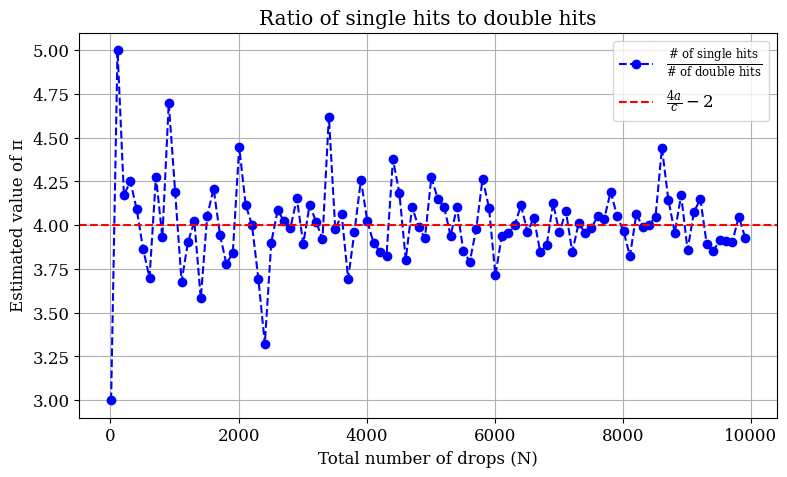

In [88]:
# Plot this ratio!
npGridTotalhits = np.array(hits_perp_final)
npGridBothhits = np.array(both_hits_perp_final)

plt.figure(figsize=(9,5))
plt.plot(N_values, (npGridTotalhits-npGridBothhits)/npGridBothhits, marker='o', linestyle='--', color='blue', label=r'$\frac{\text{# of single hits}}{\text{# of double hits}}$')
plt.axhline(4*Dperp/Lperp-2, color='red', linestyle='--', label=r'$\frac{4a}{c} - 2$')
plt.xlabel("Total number of drops (N)")
plt.ylabel("Estimated value of π")
plt.title("Ratio of single hits to double hits")

plt.grid(True)
plt.legend()
plt.show()

## Note to user

The monte-carlo method is inherently stochastic, so do not be surprised by varying results per run. However, the general trend of the error decreasing across iterations is expected across any and all runs.